# Linear and Polynomial Regression on House Dataset

First, we import all the necessary libraries for data manipulation, formatting, visualization, and building our regression models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import date
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

## Data Loading and Initial Exploration

We load the dataset using `pandas` and perform some basic exploratory data analysis (EDA) to understand its shape, columns, missing values, summary statistics, and duplicate rows.

In [4]:
df = pd.read_csv(r'F:\HUAWEL_AI\GitHub_final\Data_CSV\house_dataset.csv')

print("Dataset shape:", df.shape)

print("\nDataFrame Columns",df.columns)

print("\nColumn information:",df.info())

print("\nMissing values (Null):",df.isnull().sum())

print("\nBasic statistics:",df.describe())

print("\nDuplicated:",df.duplicated().sum())

Dataset shape: (21613, 21)

DataFrame Columns Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      2

Let's view the first few rows of our dataframe to see what the raw data looks like.

In [34]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Data Preprocessing

We convert the `date` column from object type to `datetime` objects, and then format it to a standard 'YYYY-MM-DD' string to standardize the time representation.

In [35]:
df['date'] = pd.to_datetime(df['date'])
df['date'] = df['date'].dt.strftime('%Y-%m-%d')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


## Feature Engineering

We calculate the `age` of each house by subtracting the year it was built (`yr_built`) from the current year. This 'age' feature is typically more informative for a regression model than the raw 'year built' metric.

In [36]:
current_year = date.today().year
df['age'] =current_year-df['yr_built']
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,age
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,71
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,75
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,93
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,61
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,1530,0,2009,0,98103,47.6993,-122.346,1530,1509,17
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,2310,0,2014,0,98146,47.5107,-122.362,1830,7200,12
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,1020,0,2009,0,98144,47.5944,-122.299,1020,2007,17
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,1600,0,2004,0,98027,47.5345,-122.069,1410,1287,22


## Feature Selection via Correlation

Here, we define a function `select_features_by_correlation` to help us identify which features strongly correlate with a target variable (in this case, `price`). It calculates the correlation matrix, drops highly correlated items beyond a threshold, and plots the matrix using Seaborn.

In [ ]:
def select_features_by_correlation(df, target_col, threshold):
    """
    Select features based on correlation with target variable
    """
    # Create correlation matrix
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()

    # Plot heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    # Get correlation with target
    target_corr = corr_matrix[target_col].sort_values(ascending=False)

    print(f"Top 10 features correlated with {target_col}:")
    print(target_corr.head(10))

    print(f"\nBottom 10 features correlated with {target_col}:")
    print(target_corr.tail(10))

    # Select features with correlation above threshold (absolute value)
    selected_features = target_corr[abs(target_corr) > threshold].index.tolist()
    selected_features.remove(target_col)  # Remove target from features

    print(f"\nSelected {len(selected_features)} features with |correlation| > {threshold}")

    return selected_features, corr_matrix


We invoke our feature selection function on the dataset to view the correlation heatmap and find out which features to keep.

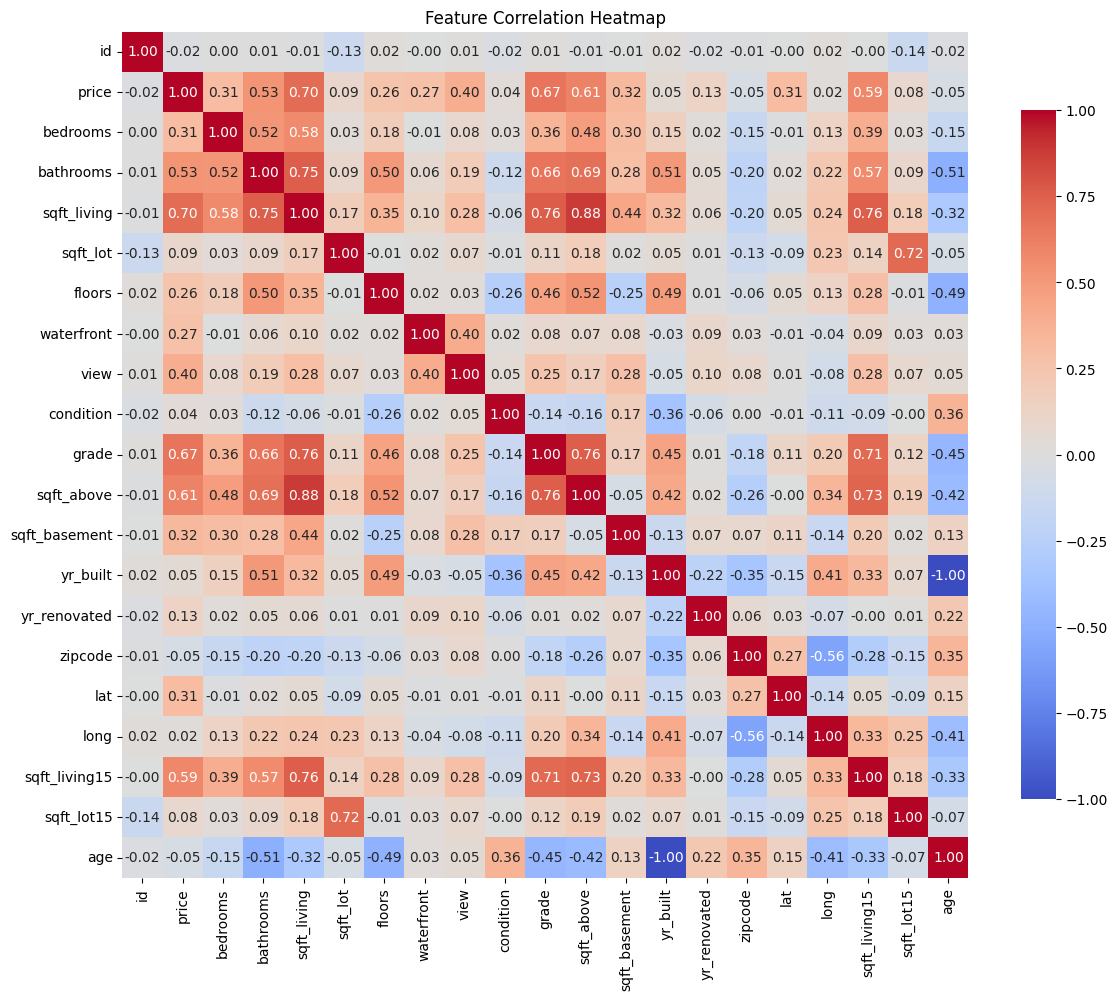

Top 10 features correlated with price:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
Name: price, dtype: float64

Bottom 10 features correlated with price:
floors          0.256794
yr_renovated    0.126434
sqft_lot        0.089661
sqft_lot15      0.082447
yr_built        0.054012
condition       0.036362
long            0.021626
id             -0.016762
zipcode        -0.053203
age            -0.054012
Name: price, dtype: float64

Selected 12 features with |correlation| > 0.1


In [38]:
selected_features, corr_matrix = select_features_by_correlation(df, 'price', threshold=0.1)

In [39]:
df.drop(['date','age','zipcode','id','long','condition','yr_built','sqft_lot15','sqft_lot','yr_renovated','floors','waterfront','view','lat'],axis = 1 , inplace = True )

We invoke our feature selection function on the dataset to view the correlation heatmap and find out which features to keep.

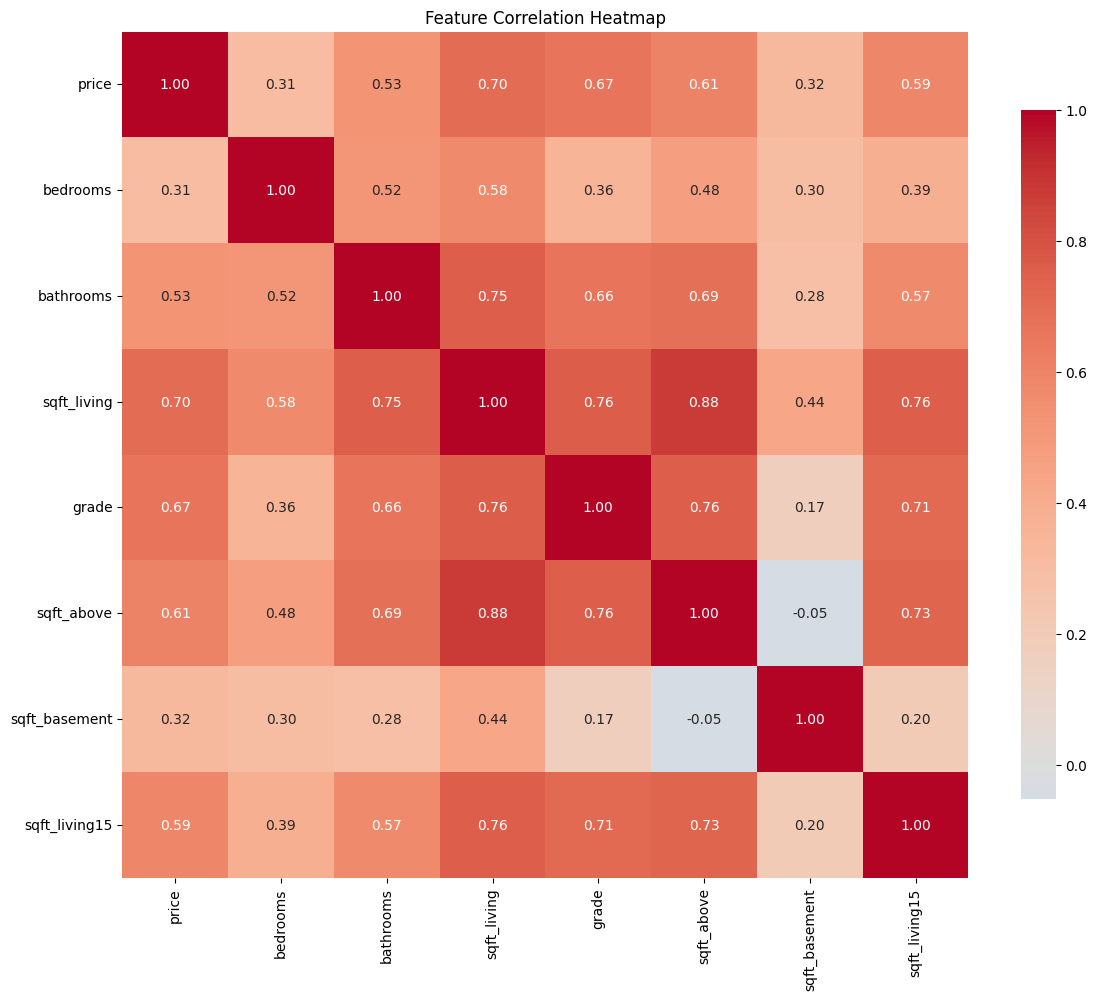

Top 10 features correlated with price:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
sqft_basement    0.323816
bedrooms         0.308350
Name: price, dtype: float64

Bottom 10 features correlated with price:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
sqft_basement    0.323816
bedrooms         0.308350
Name: price, dtype: float64

Selected 7 features with |correlation| > 0.1


In [40]:
selected_features, corr_matrix = select_features_by_correlation(df, 'price', threshold=0.1)

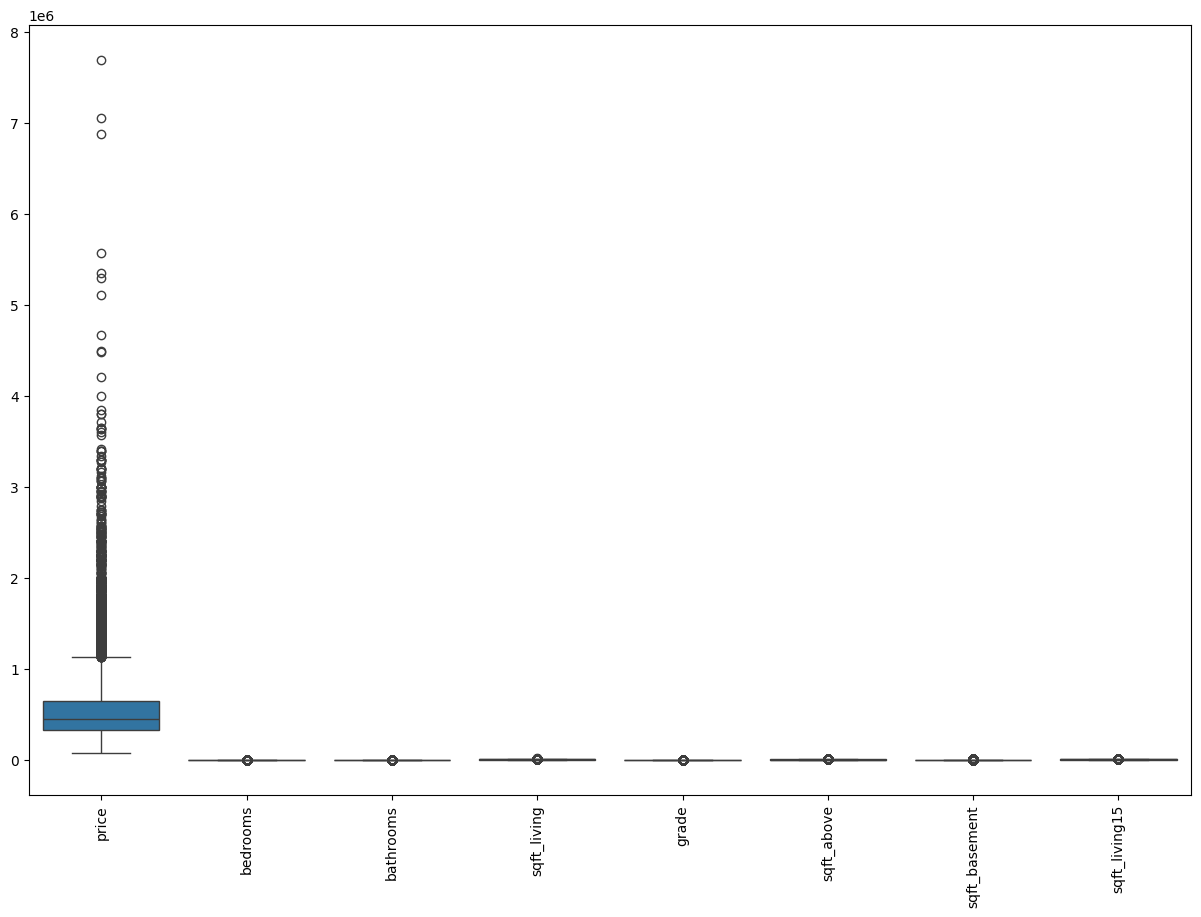

In [41]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

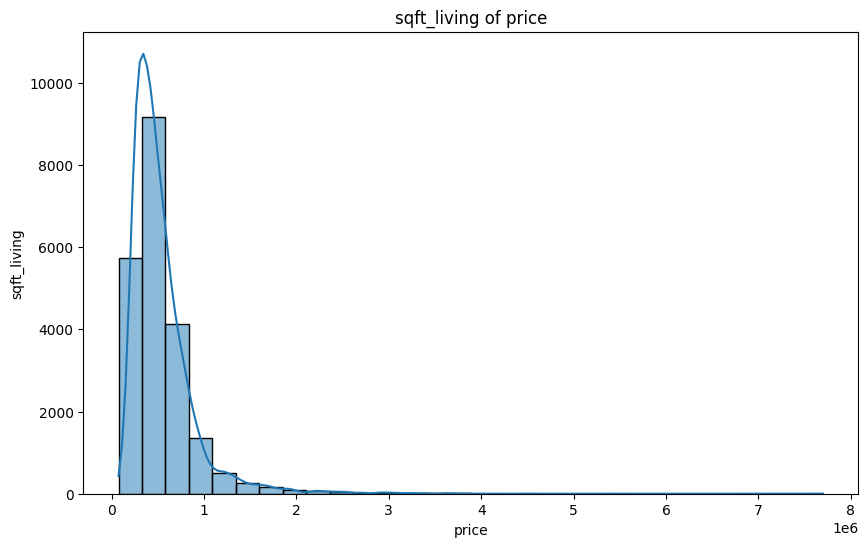

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('sqft_living of price')
plt.xlabel('price')
plt.ylabel('sqft_living')
plt.show()

In [43]:
df['price'] = np.log1p(df['price'])

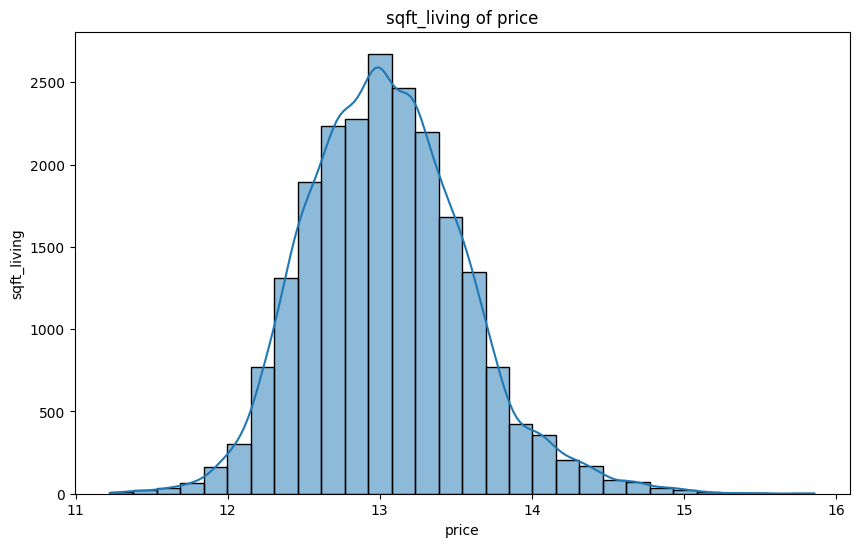

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('sqft_living of price')
plt.xlabel('price')
plt.ylabel('sqft_living')
plt.show()

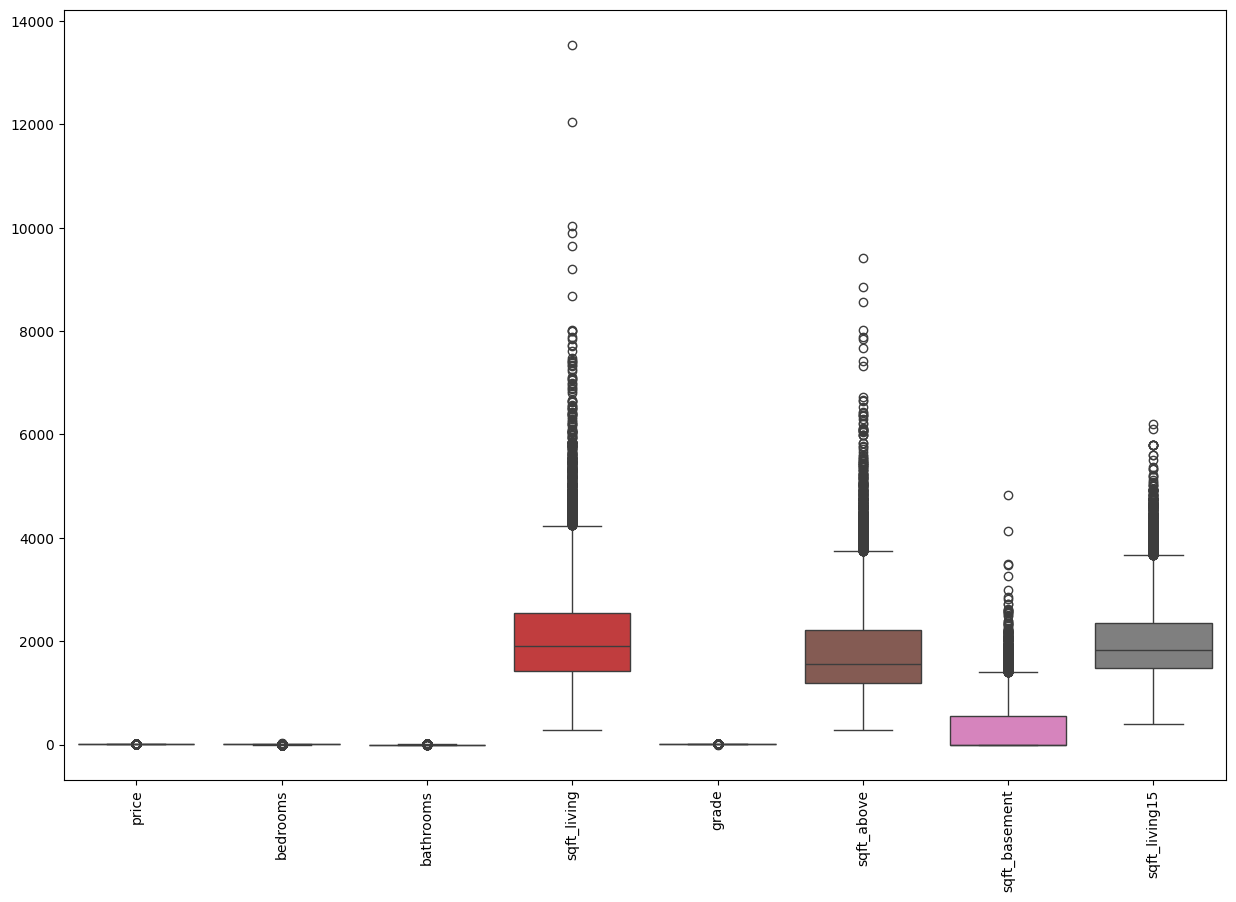

In [45]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [46]:
def outlier(df, col):
  rows = df[col]
  Q1 = np.percentile(rows, 25)
  Q3 = np.percentile(rows, 75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  filtered_rows = (rows >= lower_bound) & (rows <= upper_bound)
  return df.loc[filtered_rows]

In [47]:
df =outlier(df,'sqft_living')
df =outlier(df,'sqft_above')
df =outlier(df,'sqft_basement')
df =outlier(df,'sqft_living15')

In [48]:
y = df['price']
x = df.drop('price', axis=1)

## Splitting Data and Feature Scaling

We split our data into training and testing sets. Following that, we apply necessary transformations, such as logarithmic scaling to normalize the skewed distribution, reducing the impact of outliers on our machine learning models.

In [49]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Linear Regression Model

We initialize a basic `LinearRegression` model and fit it to our training data.

In [50]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


We use the trained linear model to predict house prices on our testing set.

In [51]:
y_pred = model.predict(x_test)
y_pred

array([13.39934182, 12.63179583, 13.10095575, ..., 12.98975618,
       12.88410442, 13.41823649], shape=(3984,))

### Evaluation Metrics (Linear Model)

We evaluate the regression model using standard metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared score. We also compute an average accuracy percentage.

In [52]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

accuracy_percentage = 100 - (abs(y_test - y_pred) / y_test * 100)
acc = accuracy_percentage.mean()

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R-squared: {r2}')
print(f"Accuracy: {acc:.2f}")

MAE: 0.2752893709646918
MSE: 0.11725553035452463
RMSE: 0.34242594871668913
R-squared: 0.466595070786739
Accuracy: 97.87


## Polynomial Regression

Since standard linear regression might fail to capture non-linear relationships in the housing data, we generate polynomial features up to a specified degree to increase our model's complexity.

In [53]:
degree = 7
poly_reg = PolynomialFeatures(degree=degree)
x_poly = poly_reg.fit_transform(x_train)
x_test_poly = poly_reg.transform(x_test)

We fit a new Linear Regression model using the expanded polynomial features.

In [54]:
poly_reg_model = LinearRegression()
poly_reg_model.fit(x_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


We then make fresh predictions on the test set using our polynomial regression model.

In [55]:
poly_pred = poly_reg_model.predict(x_test_poly)
poly_pred

array([13.31989854, 12.60419068, 13.01934436, ..., 13.03378501,
       12.81146532, 13.4157472 ], shape=(3984,))

### Evaluation Metrics (Polynomial Model)

We evaluate the polynomial regression model similarly to compare its performance against the basic linear model.

In [56]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

accuracy_percentage = 100 - (abs(y_test - y_pred) / y_test * 100)
acc = accuracy_percentage.mean()

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R-squared: {r2}')
print(f"Accuracy: {acc:.2f}")

MAE: 0.2752893709646918
MSE: 0.11725553035452463
RMSE: 0.34242594871668913
R-squared: 0.466595070786739
Accuracy: 97.87
